## 2D-IR intencities - expressions

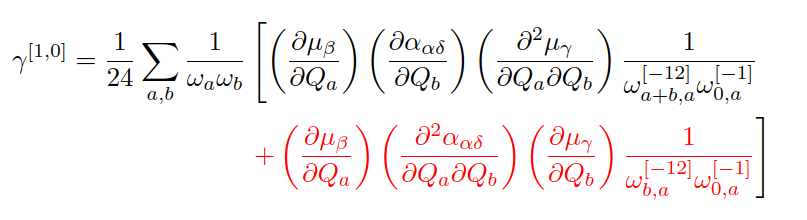

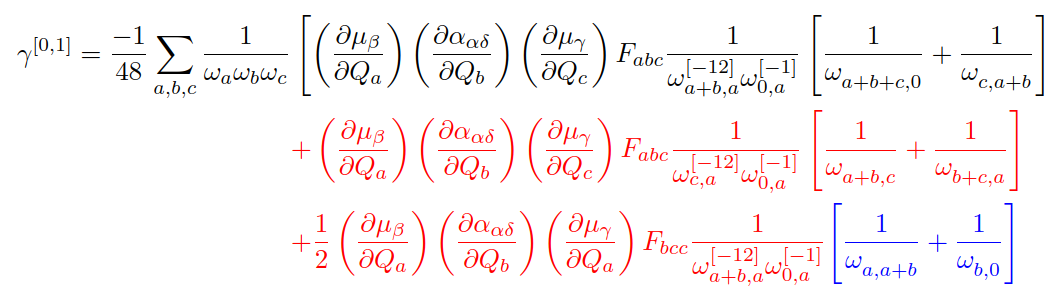

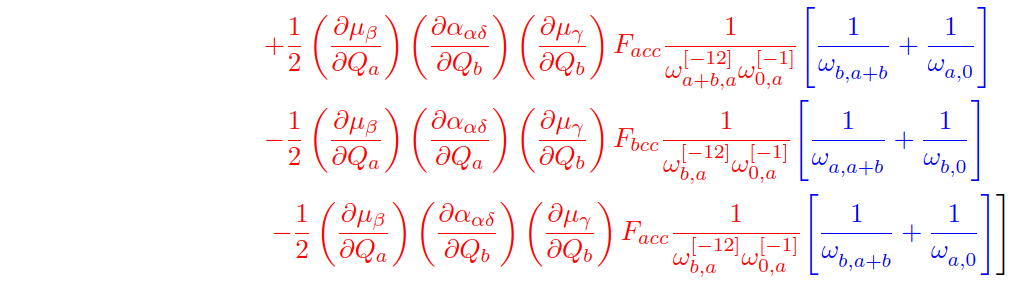

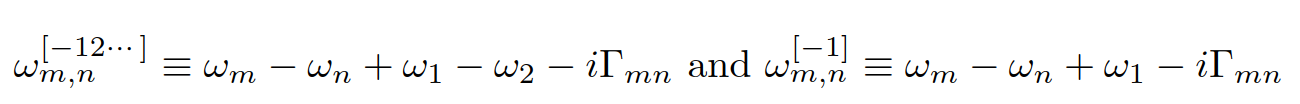

## New `class spectrumEVV`

In [9]:
import copy
import numpy as np
np.set_printoptions(linewidth=100000)

%matplotlib widget
from ipywidgets import *

class DerivResonanceTerm:
    """
    
    """

class SpectrumEVV:
    
    def __init__(self, w1, w2, fundamentals, Gamma):
        
        self.w1, self.w2 = np.meshgrid(w1, w2)
        self.shape2d = self.w1.shape
        self.fundamentals = fundamentals
        
        self.fermirm = 0.0001
        
        self.t1el = lambda w, w1, w2, Gamma, a, b: \
            1 / (w[''.join(sorted(str(a)+str(b)))] - w[str(a)] + w1 - w2 - 1j*Gamma) / (0. - w[str(a)] + w1 - 1j*Gamma)

        self.t2el = lambda w, w1, w2, Gamma, a, b: \
            1 / (w[str(b)] - w[str(a)] + w1 - w2 - 1j*Gamma) / (0. - w[str(a)] + w1 - 1j*Gamma)

        self.t1mech = lambda w, w1, w2, Gamma, a, b, c: \
            1 / (w[''.join(sorted(str(a)+str(b)))] - w[str(a)] + w1 - w2 - 1j*Gamma) / (0. - w[str(a)] + w1 - 1j*Gamma) * \
           (1 / (w[''.join(sorted(str(a)+str(b)+str(c)))] - 0. + self.fermirm) \
          + 1 / ( w[str(c)] - w[''.join(sorted(str(a)+str(b)))] + self.fermirm))
        
        self.t2mech = lambda w, w1, w2, Gamma, a, b, c: \
            1 / (w[str(c)] - w[str(a)] + w1 - w2 - 1j*Gamma) / (0. - w[str(a)] + w1 - 1j*Gamma) * \
           (1 / (w[''.join(sorted(str(a)+str(b)))] - w[str(c)] + self.fermirm) \
          + 1 / (w[''.join(sorted(str(a)+str(b)))] - w[str(a)] + self.fermirm))
        
        self.t3mech = lambda w, w1, w2, Gamma, a, b, c: \
            1 / (w[''.join(sorted(str(a)+str(b)))] - w[str(a)] + w1 - w2 - 1j*Gamma) / (0. - w[str(a)] + w1 - 1j*Gamma) * \
           (1 / (w[str(a)] - w[''.join(sorted(str(a)+str(b)))] + self.fermirm) \
          + 1 / (w[str(b)] - 0. + self.fermirm))
        
        self.t4mech = lambda w, w1, w2, Gamma, a, b, c: \
            1 / (w[''.join(sorted(str(a)+str(b)))] - w[str(a)] + w1 - w2 - 1j*Gamma) / (0. - w[str(a)] + w1 - 1j*Gamma) * \
           (1 / (w[str(b)] - w[''.join(sorted(str(a)+str(b)))] + self.fermirm) \
          + 1 / (w[str(a)] - 0. + self.fermirm))
        
        elements = list(self.fundamentals.keys())
        pairs = [a + b for i, a in enumerate(elements) for b in elements[i:]]
        triples = [a + b + c for i, a in enumerate(elements) for j, b in enumerate(elements[i:]) for c in elements[j:]]

        self.Delta = {k:sum([self.fundamentals[i] for i in k]) for k in [*pairs, *triples]}
        
        self.Gamma = Gamma
    
    def gamma_mn(self, a, b, c=False):
        new_states = copy.deepcopy(self.fundamentals)
        new_states.update(self.Delta)
        
        if type(c)==bool:
            
            total_sum_el = np.zeros(self.shape2d, dtype=('complex128'))
            
            gammaCompsAll = getting_abcgreek4avrg(num_f=4)
            averg_el = avrg_abc(formats, data, [a, b, c], gammaCompsAll)
            prefac_el = 1 / self.fundamentals[str(a)] / self.fundamentals[str(b)]

            # electrical
            total_sum_el += prefac_el * averg_el * self.t1el(new_states, self.w1, self.w2, self.Gamma, a, b)
            total_sum_el += prefac_el * averg_el * self.t2el(new_states, self.w1, self.w2, self.Gamma, a, b)
            
            return total_sum_el/24
            
        else:
            
            total_sum_mech = np.zeros(self.shape2d, dtype=('complex128'))
            
            # mechanical
            averg_mech = 1
            prefac_mech = 1 / self.fundamentals[str(a)] / self.fundamentals[str(b)] / self.fundamentals[str(c)]

            total_sum_mech += prefac_mech * averg_mech * self.t1mech(new_states, self.w1, self.w2, self.Gamma, a, b, c)
            # print(total_sum_mech)
            #total_sum_mech += prefac_mech * averg_mech * self.t2mech(new_states, self.w1, self.w2, self.Gamma, a, b, c)
            #print(total_sum_mech)
            #total_sum_mech += (1/2) * prefac_mech * averg_mech * self.t3mech(new_states, self.w1, self.w2, self.Gamma, a, b, c)
            #print(total_sum_mech)
            #total_sum_mech += (1/2) * prefac_mech * averg_mech * self.t4mech(new_states, self.w1, self.w2, self.Gamma, a, b, c)
            # print('-----------')
            return -total_sum_mech/48.
    
    
    def plot2D(self, coords_ab, coords_abc=[], w1mw2=False):
        import matplotlib.pyplot as plt
        from matplotlib import cm, ticker, colors
        
        X, Y = self.w1, self.w2
        # a, b, c = np.arange(len(self.fundamentals)), np.arange(len(self.fundamentals)), np.arange(len(self.fundamentals))
        
        Z = np.zeros(self.shape2d, dtype=('complex128'))
        
        for i in coords_ab:
            # print(i, self.fundamentals[str(i[0])], self.fundamentals[str(i[1])])
            # added = self.gamma_mn(i[0], i[1])
            # x_index = np.where(self.w1 == self.fundamentals[str(i[0])])[0][0]
            # y_index = np.where(self.w2 == self.fundamentals[str(i[1])])[0][0]
            
            # print(added[y_index, x_index])
            # print(added[y_index+5, x_index+5])
            
            Z += self.gamma_mn(i[0], i[1])
        
        for i in coords_abc:
            Z += self.gamma_mn(i[0], i[1], i[2])
        
        # print(Z)
        
        # PLOTTING
        fig, ax = plt.subplots()
        fig.set_size_inches(11, 9)

        ax.set_xlabel('w1', fontsize=18)

        if w1mw2:
            y = (X-Y) 
            ax.set_ylabel('-(w1-w2)', fontsize=18)

        else: 
            y = Y
            ax.set_ylabel('w2', fontsize=18)

        cp = ax.contourf(X, y, abs(Z)**2, 8, cmap='magma')

        cb = fig.colorbar(cp)

        ax.set_xticks(np.linspace(min(X.flatten()), max(X.flatten()), 10))
        ax.set_yticks(np.linspace(min(y.flatten()), max(y.flatten()), 10))
            
        plt.show()
        
    def plot2D_surface(self, coords_ab, coords_abc=[], w1mw2=False):
        import matplotlib.pyplot as plt
        from matplotlib import cm, ticker, colors
        from mpl_toolkits.mplot3d import axes3d
        
        X, Y = self.w1, self.w2
        # a, b, c = np.arange(len(self.fundamentals)), np.arange(len(self.fundamentals)), np.arange(len(self.fundamentals))
        
        # coords_ab = get_abc(2, len(self.fundamentals))
        # coords_ab = [[0, 0], [0, 1]]
        Z = np.zeros(self.shape2d, dtype=('complex128'))
        
        for i in coords_ab:
            # print(i, self.fundamentals[str(i[0])], self.fundamentals[str(i[1])])
            # added = self.gamma_mn(i[0], i[1])
            # x_index = np.where(self.w1 == self.fundamentals[str(i[0])])[0][0]
            # y_index = np.where(self.w2 == self.fundamentals[str(i[1])])[0][0]
            
            # print(added[y_index, x_index])
            # print(added[y_index+5, x_index+5])
            
            Z += self.gamma_mn(i[0], i[1])

        for i in coords_abc:
            Z += self.gamma_mn(i[0], i[1], i[2])
        
        ax = plt.figure(figsize=(11, 9)).add_subplot(projection='3d')
        
        ax.set_xlabel('w1', fontsize=18)

        if w1mw2:
            y = (X-Y) 
            ax.set_ylabel('-(w1-w2)', fontsize=18)

        else: 
            y = Y
            ax.set_ylabel('w2', fontsize=18)

        # ax.plot_surface(X, y, abs(Z)**2, edgecolor='royalblue', lw=0.5, rstride=8, cstride=8, alpha=0.3)
        # ax.bar3d(X, y, Z, 5, 5, (abs(Z)**2).flatten())
        
        pp = ax.plot_surface(X, y, abs(Z)**2, cmap='magma')
        plt.tight_layout()
        
        plt.show()
        # return fig


def get_abc(nloops, abcrange):
    stacklist = []
    for i in range(nloops):
        stacklist.append(np.arange(abcrange))
    
    return np.stack(np.meshgrid(*stacklist), axis=-1).reshape(-1, nloops)

{'00': 40, '01': 50, '02': 70, '11': 60, '12': 80, '22': 100, '000': 60, '001': 70, '002': 90, '011': 80, '012': 100, '022': 120, '110': 80, '111': 90, '112': 110, '121': 110, '122': 130, '220': 120, '221': 130, '222': 150}


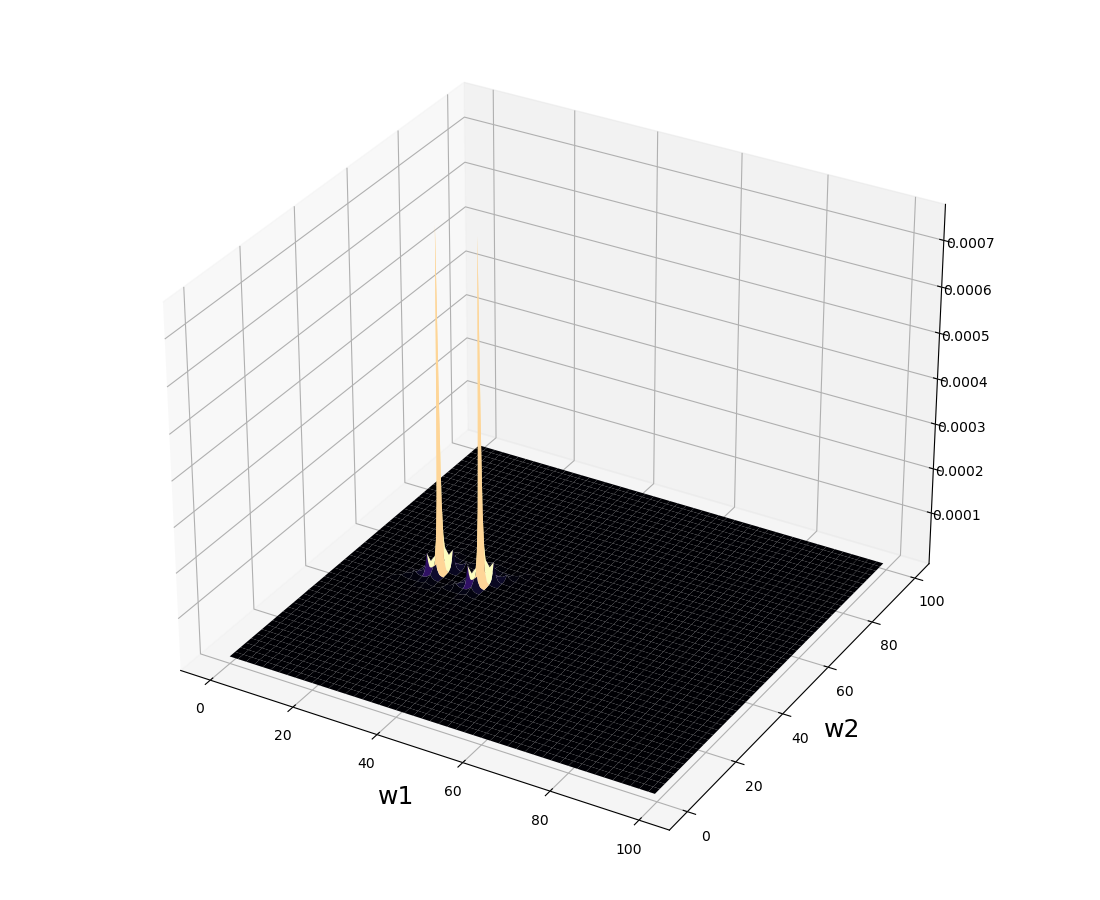

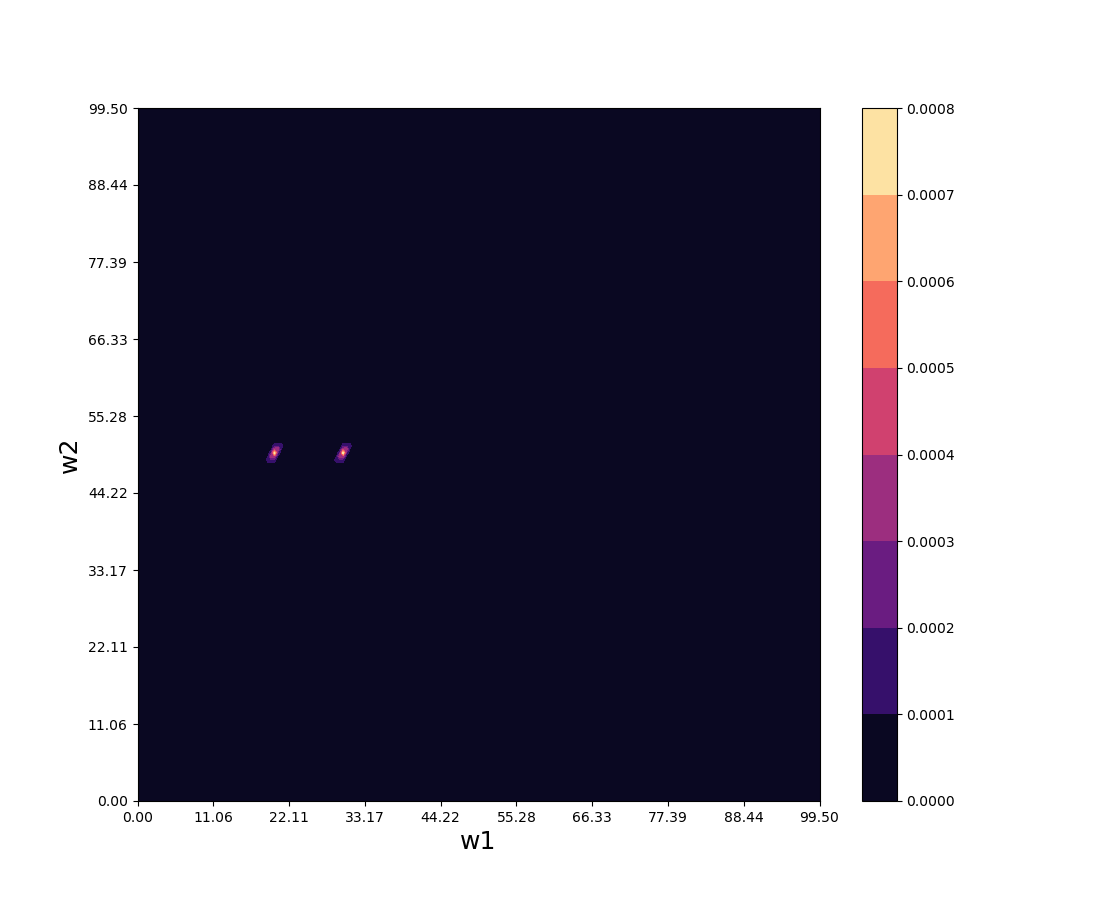

In [10]:
w1 = np.arange(0., 100,0.5)
w2 = np.arange(0, 100, 0.5)
X, Y = np.meshgrid(w1, w2)

fundamentals = {'0':20, '1':30
           , '2':50
         }

h = SpectrumEVV(w1, w2, fundamentals, Gamma=10**(-0.3))
print(h.Delta)

# coords_ab = get_abc(2, len(h.fundamentals))
abc = get_abc(3, len(h.fundamentals))

# coords_ab = [[0, 0], [0, 1], [0, 2], [1, 0], [1, 1], [1, 2], [2, 0], [2, 1], [2, 2]]
coords_ab = []
h.plot2D_surface(coords_ab, abc)
h.plot2D(coords_ab, abc)

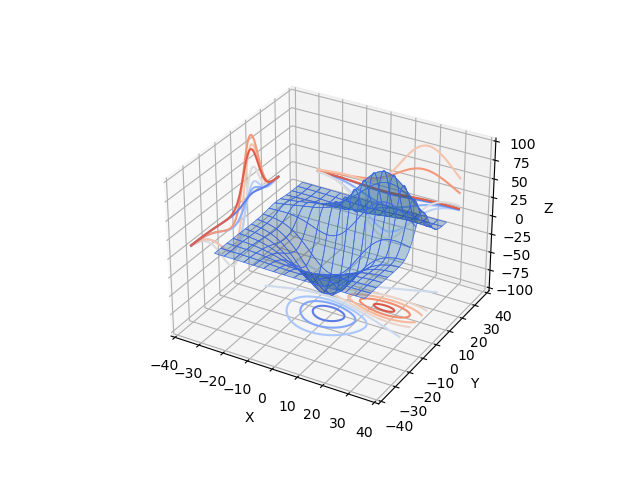

In [3]:
from mpl_toolkits.mplot3d import axes3d
import matplotlib.pyplot as plt

ax = plt.figure().add_subplot(projection='3d')
X, Y, Z = axes3d.get_test_data(0.05)

# Plot the 3D surface
ax.plot_surface(X, Y, Z, edgecolor='royalblue', lw=0.5, rstride=8, cstride=8,
                alpha=0.3)

# Plot projections of the contours for each dimension.  By choosing offsets
# that match the appropriate axes limits, the projected contours will sit on
# the 'walls' of the graph.
ax.contour(X, Y, Z, zdir='z', offset=-100, cmap='coolwarm')
ax.contour(X, Y, Z, zdir='x', offset=-40, cmap='coolwarm')
ax.contour(X, Y, Z, zdir='y', offset=40, cmap='coolwarm')

ax.set(xlim=(-40, 40), ylim=(-40, 40), zlim=(-100, 100),
       xlabel='X', ylabel='Y', zlabel='Z')

plt.show()